In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
from scipy.stats import multivariate_normal

In [2]:
import sklearn

In [25]:
def f(chi):
    return np.sqrt((1+np.sqrt(1-chi**2))/2)

In [26]:
sigma = 0.02
N_points = 1000

In [27]:
Mirr = []
chi = []
for i in range(10):
    chii = scipy.stats.uniform.rvs(0, 1, N_points)
    chi = np.append(chi,chii)
    M = norm.rvs(1,sigma,N_points)
    Mirri = M*f(chii)
    Mirr = np.append(Mirr, Mirri)

(array([0.18586896, 0.44280547, 0.92114472, 1.57441946, 2.09375921,
        3.11603851, 5.16059711, 8.87797638, 4.7123249 , 0.24873641]),
 array([0.70525071, 0.74183562, 0.77842053, 0.81500545, 0.85159036,
        0.88817527, 0.92476019, 0.9613451 , 0.99793002, 1.03451493,
        1.07109984]),
 <BarContainer object of 10 artists>)

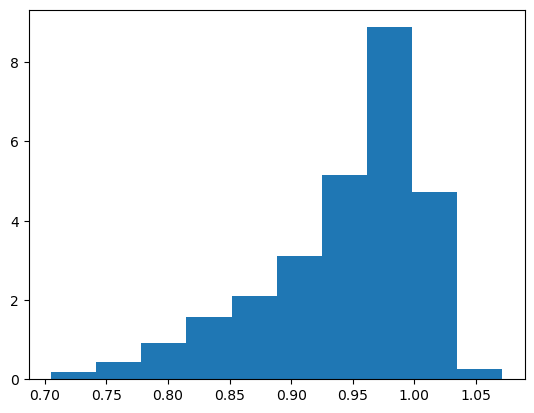

In [28]:
plt.hist(Mirr,density=True)

[]

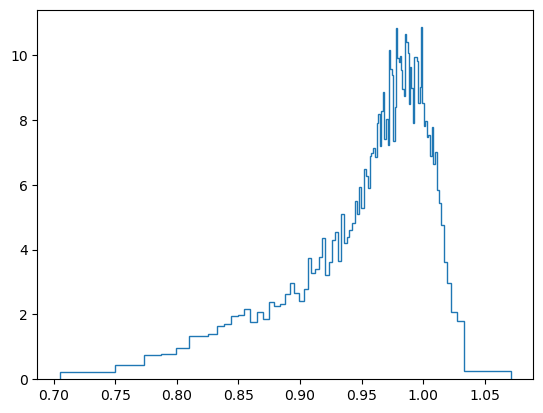

In [29]:
bins100 = np.append(np.sort(Mirr)[::100], np.max(Mirr)) 
plt.hist(Mirr, bins=bins100, density=True, histtype="step") 
plt.plot()

(array([0.06639429, 0.13278858, 0.21246173, 0.19918287, 0.33197145,
        0.39836574, 0.27885602, 0.45148117, 0.51787546, 0.58426975,
        0.95607777, 0.73033719, 0.90296234, 0.99591435, 1.28804922,
        1.36772237, 1.4208378 , 1.50051095, 2.00510756, 1.96527098,
        1.96527098, 2.00510756, 2.05822299, 2.32380015, 2.58937731,
        2.64249274, 2.96118533, 3.43922422, 3.71808024, 4.06333054,
        4.43513857, 4.68743687, 5.80286094, 6.51991927, 7.91419936,
        8.44535368, 9.52094117, 9.37487374, 9.34831602, 7.67517991,
        6.46680384, 4.05005168, 2.337079  , 1.18181836, 0.6639429 ,
        0.19918287, 0.01327886, 0.06639429, 0.01327886]),
 array([0.70525071, 0.71278147, 0.72031224, 0.72784301, 0.73537378,
        0.74290455, 0.75043531, 0.75796608, 0.76549685, 0.77302762,
        0.78055839, 0.78808915, 0.79561992, 0.80315069, 0.81068146,
        0.81821223, 0.825743  , 0.83327376, 0.84080453, 0.8483353 ,
        0.85586607, 0.86339684, 0.8709276 , 0.87845837, 0.

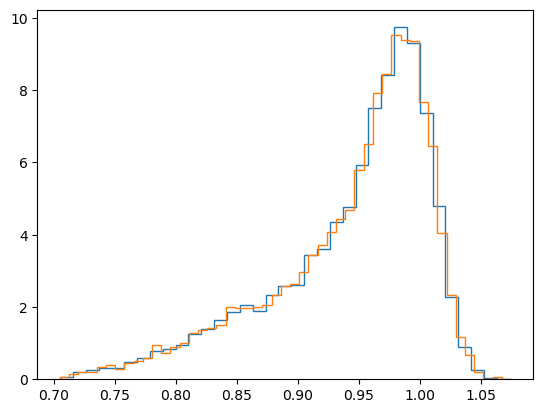

In [30]:
import astropy.visualization.hist
astropy.visualization.hist(Mirr, bins="scott", histtype="step",density=True)
astropy.visualization.hist(Mirr, bins="freedman", histtype="step",density=True)

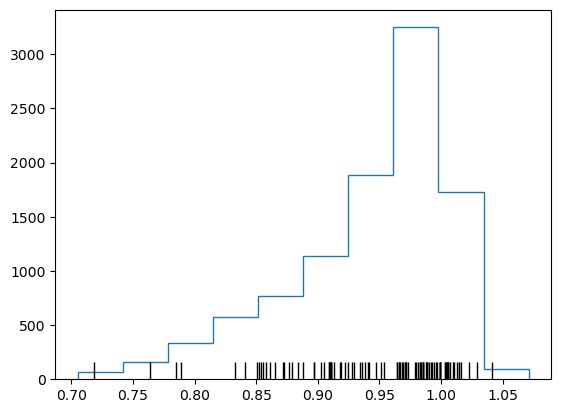

In [31]:
plt.hist(Mirr,histtype="step")
plt.plot(Mirr[:100], 0*Mirr[:100], '|', color='k', markersize=25);

In [32]:
from sklearn.neighbors import KernelDensity

In [33]:
xgrid = np.linspace(Mirr.min(),Mirr.max(),10000)

In [34]:
def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

[]

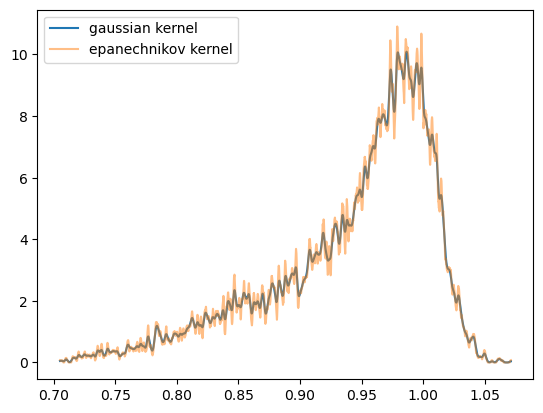

In [35]:
PDFtophat = kde_sklearn(Mirr,bandwidth=0.001,kernel="gaussian") 
plt.plot(xgrid,PDFtophat,label='gaussian kernel',alpha = 1)
PDFtophat = kde_sklearn(Mirr,bandwidth=0.001,kernel="epanechnikov") 
plt.plot(xgrid,PDFtophat,label='epanechnikov kernel',alpha = 0.5)
plt.legend()
plt.plot()

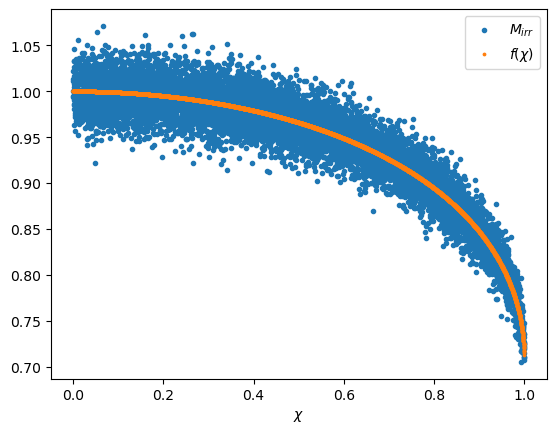

In [39]:
plt.scatter(chi,Mirr,marker='.', label=r'$M_{irr}$')
plt.scatter(chi,f(chi),s=3, label=r'$f(\chi)$')
plt.xlabel(r'$\chi$')
plt.legend()

In [40]:
print(stats.ks_2samp(Mirr,f(chi)))

KstestResult(statistic=0.1612, pvalue=9.109734045566117e-114, statistic_location=0.9999999997795149, statistic_sign=-1)


In [41]:
N_sigma = 30
sigmas= np.logspace(-5,1,N_sigma)
sigmas

array([1.00000000e-05, 1.61026203e-05, 2.59294380e-05, 4.17531894e-05,
       6.72335754e-05, 1.08263673e-04, 1.74332882e-04, 2.80721620e-04,
       4.52035366e-04, 7.27895384e-04, 1.17210230e-03, 1.88739182e-03,
       3.03919538e-03, 4.89390092e-03, 7.88046282e-03, 1.26896100e-02,
       2.04335972e-02, 3.29034456e-02, 5.29831691e-02, 8.53167852e-02,
       1.37382380e-01, 2.21221629e-01, 3.56224789e-01, 5.73615251e-01,
       9.23670857e-01, 1.48735211e+00, 2.39502662e+00, 3.85662042e+00,
       6.21016942e+00, 1.00000000e+01])

/tmp/ipykernel_146553/1844867091.py:10: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  KSs_f = np.append(KSs_f, stats.ks_2samp(Mirri,f(chi))[1])


Text(0.5, 0, '$M_{irr}$')

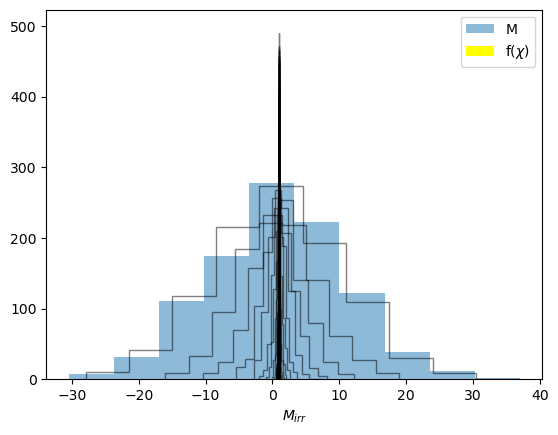

In [42]:
KSs_f = []
KSs_M = []

for i in range(N_sigma):
    chi = scipy.stats.uniform.rvs(0, 1, N_points)
    M = norm.rvs(1,sigmas[i],N_points)
    Mirri = M*f(chi)
    plt.hist(Mirri,histtype="step",color='k',alpha=0.5)
    
    KSs_f = np.append(KSs_f, stats.ks_2samp(Mirri,f(chi))[1])
    KSs_M = np.append(KSs_M, stats.ks_2samp(Mirri,M)[1])

plt.hist(M,alpha=0.5,label='M')
plt.hist(f(chi),alpha=1,color='yellow',label=r'f($\chi$)')
plt.legend()
plt.xlabel(r'$M_{irr}$')

Text(0, 0.5, 'KS M$_{irr}$-f')

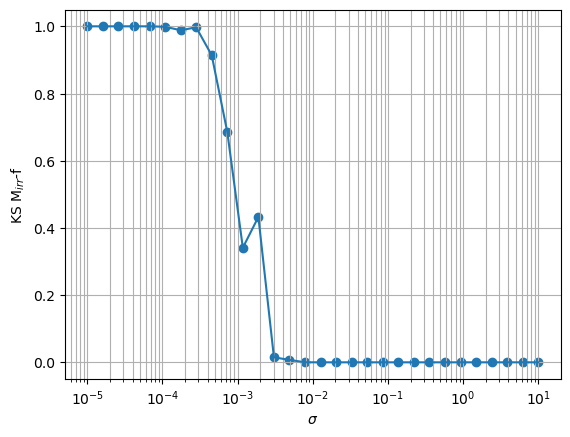

In [43]:
plt.grid(which='both')
plt.plot(sigmas, KSs_f)
plt.scatter(sigmas, KSs_f)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r'$\sigma$')
plt.ylabel(r'KS M$_{irr}$-f')


Text(0, 0.5, 'KS M$_{irr}$-M')

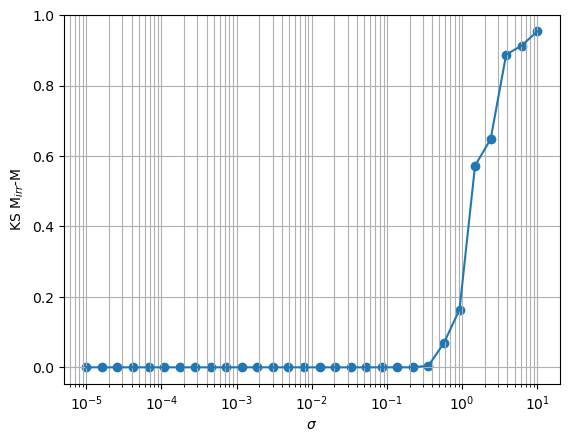

In [44]:
plt.grid(which='both')
plt.plot(sigmas, KSs_M)
plt.scatter(sigmas, KSs_M)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r'$\sigma$')
plt.ylabel(r'KS M$_{irr}$-M')

In [45]:
from tqdm.notebook import tqdm

In [46]:
def p_f(f):
    return 2*(2*f**2-1)/np.sqrt(1-f**2)
def integrand(f,x):
    return ((2/np.pi)**0.5 / sigma ) * np.exp(-(x/f -1)**2 /(2*sigma**2)) * (2*f**2-1)/(1 - f**2)**0.5 / f
def p_Mirr(f,x):
    return [scipy.integrate.quad(lambda f: integrand(f,xt), 1/2**0.5,1)[0] for xt in tqdm(x)]

N = 10000
x = np.linspace(min(1-5*sigma,1/np.sqrt(2)),1+5*sigma,N)

Mirr_from_int = [scipy.integrate.quad(lambda f: integrand(f,xt), 1/2**0.5,1)[0] for xt in tqdm(x)]

  0%|          | 0/10000 [00:00<?, ?it/s]

[]

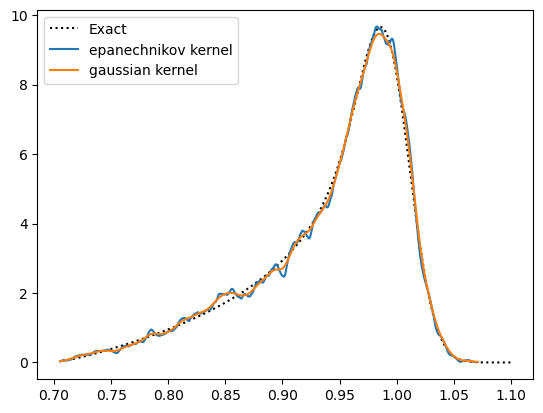

In [47]:
plt.plot(x,Mirr_from_int,label='Exact',c='black',ls=':')
PDFtophat = kde_sklearn(Mirr,bandwidth=0.005,kernel="epanechnikov") 
plt.plot(xgrid,PDFtophat,label='epanechnikov kernel',alpha = 1)
PDFtophat = kde_sklearn(Mirr,bandwidth=0.005,kernel="gaussian") 
plt.plot(xgrid,PDFtophat,label='gaussian kernel',alpha = 1)

plt.legend()
plt.plot()